## Derivable Judgement

In [19]:
# Load Your Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# Load the dataset provided
file_name = 'health_dataset_250.xlsx '
df = pd.read_excel(file_name)

# Display the internal structure to verify column names
print("Dataset successfully loaded. Shape:", df.shape)
df.head()


Dataset successfully loaded. Shape: (250, 15)


,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,d4360b49-db82-4853-866e-c82700a3d5b0,36-45,40,89,Other,North,Former Smoker,Daily,23.26,155.80,True,False,261.71,157.05,2026-02-23
1,433369ca-ad43-48b8-b887-4391e7d49112,46-60,48,79,Female,East,Non-Smoker,Never,20.80,98.65,False,False,257.21,79.28,2025-05-25
2,8bd77a92-bf8b-4c1c-993b-f2ea0a28286f,36-45,45,50,Male,West,Non-Smoker,Never,29.41,117.93,True,True,252.11,73.60,2025-06-03
3,7d21d846-146c-4a38-8993-114232630645,46-60,51,66,Other,West,Non-Smoker,Daily,27.37,149.62,True,False,181.46,75.36,2025-10-13
4,1009dc5b-e5a3-477a-86e8-50b2d5587471,46-60,54,76,Female,South,Former Smoker,Daily,19.91,143.31,False,True,158.69,92.42,2025-07-25


# Descriptive Statistics Summary

In [20]:
# Statistical overview of numerical columns
health_stats = df[['age', 'weight', 'bmi', 'blood_pressure', 'cholesterol_level', 'glucose_level']].describe()
print("--- Descriptive Statistics ---")
display(health_stats.round(2))

--- Descriptive Statistics ---


,age,weight,bmi,blood_pressure,cholesterol_level,glucose_level
count,250.00,250.00,250.00,250.00,250.00,250.00
mean,44.07,71.22,26.10,126.57,215.24,124.15
std,15.13,16.26,4.81,20.68,36.11,31.71
min,18.00,45.00,18.04,90.02,150.03,70.20
25%,31.25,57.00,22.22,109.42,185.52,96.08
50%,44.00,71.00,26.06,126.43,217.48,124.82
75%,56.00,85.00,30.05,145.26,244.73,151.39
max,70.00,100.00,34.99,159.84,279.46,179.93


# Hypothesis Formulation

In [21]:

print("Hypothesis 1:")
print("H0: Smoking has no effect on BMI")
print("H1: Smoking affects BMI")

print("\nHypothesis 2:")
print("H0: Smoking and Diabetes are independent")
print("H1: Smoking and Diabetes are related")

# 4. CONFIDENCE INTERVAL


def confidence_interval(data):
    mean = np.mean(data)
    ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=stats.sem(data))
    return mean, ci

# Age CI
age_mean, age_ci = confidence_interval(df['age'])

# Weight CI
weight_mean, weight_ci = confidence_interval(df['weight'])

print("\nAge Mean:", age_mean)
print("Age 95% CI:", age_ci)

print("\nWeight Mean:", weight_mean)
print("Weight 95% CI:", weight_ci)


Hypothesis 1:
H0: Smoking has no effect on BMI
H1: Smoking affects BMI

Hypothesis 2:
H0: Smoking and Diabetes are independent
H1: Smoking and Diabetes are related

Age Mean: 44.072
Age 95% CI: (np.float64(42.18687050739089), np.float64(45.95712949260911))

Weight Mean: 71.216
Weight 95% CI: (np.float64(69.1900310598187), np.float64(73.2419689401813))


# T-test (BMI Smoker Vs Non-Smoker)

In [22]:
group1 = df[df['smoking_status'] == "Smoker"]['bmi']
group2 = df[df['smoking_status'] == "Non-Smoker"]['bmi']

t_stat, p_val = stats.ttest_ind(group1, group2, nan_policy='omit')

alpha = 0.05
dfree = len(group1) + len(group2) - 2
critical_value = stats.t.ppf(1 - alpha/2, dfree)

print("\nT-Test Results:")
print("t-statistic:", t_stat)
print("p-value:", p_val)
print("critical value:", critical_value)

if p_val < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")



T-Test Results:
t-statistic: 1.2782396342417492
p-value: 0.20286742686985804
critical value: 1.9736914397560734
Fail to Reject H0


# Z-test (Age vs Mean=30)

In [23]:

mean_age = df['age'].mean()
std_age = df['age'].std()
n = len(df)

z = (mean_age - 30) / (std_age / np.sqrt(n))

print("\nZ-Test Value:", z)

if abs(z) > 1.96:
    print("Reject H0")
else:
    print("Fail to Reject H0")


Z-Test Value: 14.70207904024441
Reject H0


# CHI-Square Test

In [24]:
cont_table = pd.crosstab(df['smoking_status'], df['diabetes'])

chi2, p, dof, expected = stats.chi2_contingency(cont_table)

print("\nChi-Square Test:")
print("Chi2:", chi2)
print("p-value:", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")


Chi-Square Test:
Chi2: 0.9977419084150402
p-value: 0.6072158473333056
Fail to Reject H0


# Anova Test (Age Vs Disease)

In [25]:
groups = [group['diabetes'].values for name, group in df.groupby('age_group')]

f_stat, p_val = stats.f_oneway(*groups)

print("\nANOVA Test:")
print("F-stat:", f_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")


ANOVA Test:
F-stat: 0.7394000342615799
p-value: 0.5659146065890635
Fail to Reject H0


# Covariance & Correlation

In [26]:
cov = np.cov(df['age'], df['bmi'])[0][1]
corr = np.corrcoef(df['age'], df['bmi'])[0][1]

print("\nCovariance (Age vs BMI):", cov)
print("Correlation (Age vs BMI):", corr)


Covariance (Age vs BMI): 3.453641124497994
Correlation (Age vs BMI): 0.047476645786638585


# Categorical breakdown

In [27]:
# Categorical breakdown
print("--- Demographic Breakdown ---")
for col in ['gender', 'age_group', 'region']:
    print(f"\n{col.capitalize()} Distribution:")
    print(df[col].value_counts(normalize=True).map('{:.1%}'.format))

--- Demographic Breakdown ---

Gender Distribution:
gender
Female    36.0%
Male      32.4%
Other     31.6%
Name: proportion, dtype: object

Age_group Distribution:
age_group
46-60    29.2%
36-45    19.6%
60+      18.4%
26-35    16.8%
18-25    16.0%
Name: proportion, dtype: object

Region Distribution:
region
West     29.6%
North    24.8%
East     24.8%
South    20.8%
Name: proportion, dtype: object


# Prevalence of conditions

In [28]:
prevalence = df[['hypertension', 'diabetes']].mean() * 100
print("--- Health Condition Prevalence ---")
print(f"Hypertension: {prevalence['hypertension']:.1f}%")
print(f"Diabetes: {prevalence['diabetes']:.1f}%")

--- Health Condition Prevalence ---
Hypertension: 54.4%
Diabetes: 49.2%


# Visualize Distributions

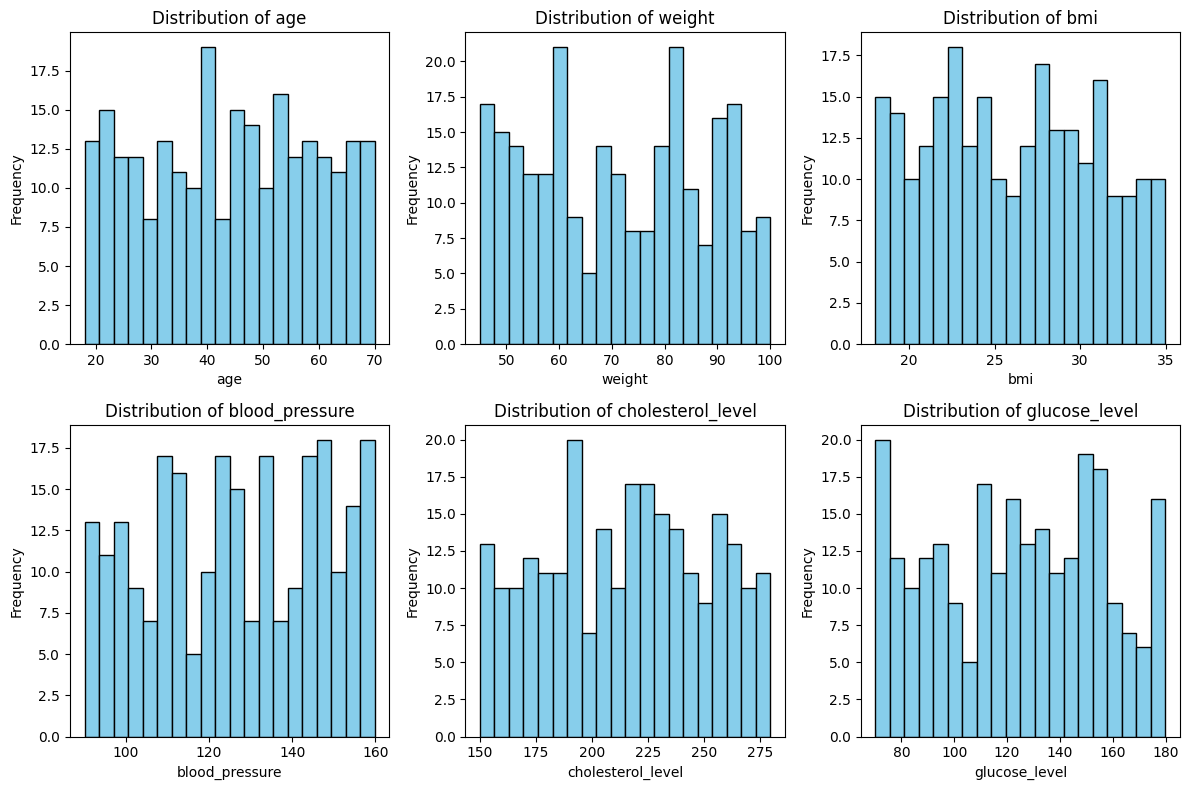

In [29]:
# Visualize distributions of key health metrics
plt.figure(figsize=(12, 8))
for i, col in enumerate(['age', 'weight', 'bmi', 'blood_pressure', 'cholesterol_level', 'glucose_level']):
    plt.subplot(2, 3, i + 1)
    plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Health Correlation Mapping

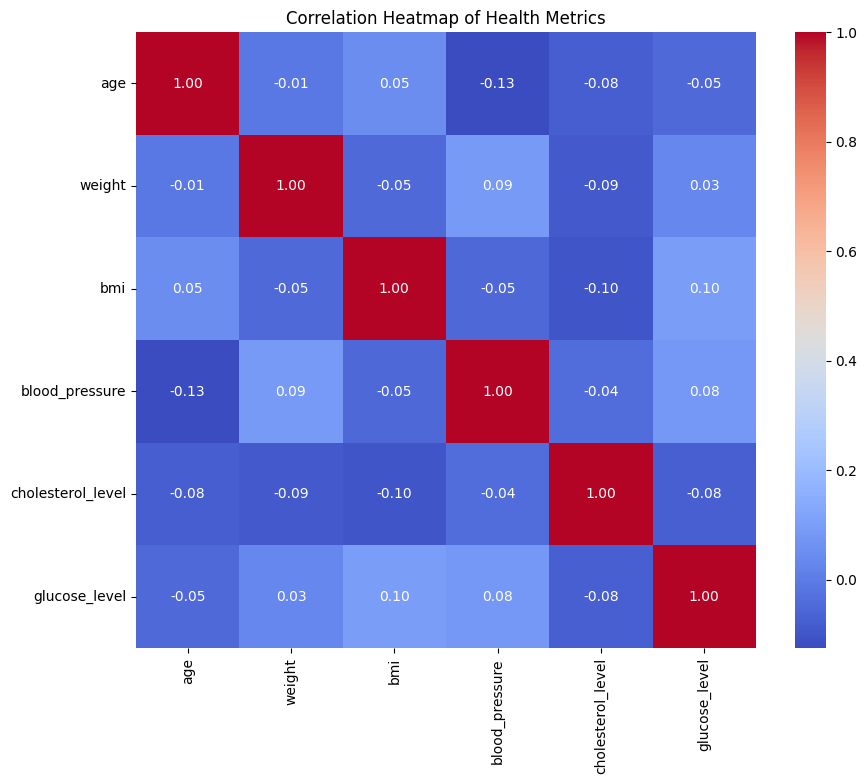

In [30]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
corr = df[['age', 'weight', 'bmi', 'blood_pressure', 'cholesterol_level', 'glucose_level']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Health Metrics')
plt.show()

# Regional Health Comparsion

In [31]:
# Grouping by region
regional_health = df.groupby('region')[['bmi', 'glucose_level', 'blood_pressure']].mean().sort_values(by='bmi', ascending=False)
print("--- Average Health Metrics by Region ---")
display(regional_health.round(2))

--- Average Health Metrics by Region ---


,bmi,glucose_level,blood_pressure
region,,,
North,26.55,125.67,124.32
West,26.32,126.54,125.85
East,25.92,118.43,127.97
South,25.46,125.74,128.64


# Risk Profiling

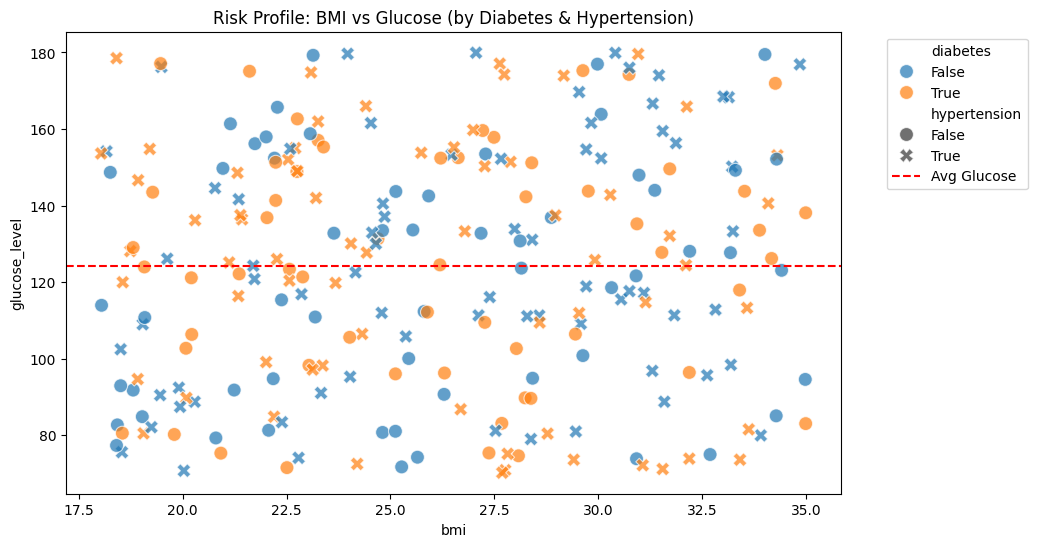

In [32]:
# Risk Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='bmi', y='glucose_level', hue='diabetes', style='hypertension', s=100, alpha=0.7)
plt.axhline(df['glucose_level'].mean(), color='red', linestyle='--', label='Avg Glucose')
plt.title('Risk Profile: BMI vs Glucose (by Diabetes & Hypertension)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Final Interpretation

In [33]:


print("\nFINAL SUMMARY:")
print("- T-test:", "Reject H0" if p_val < 0.05 else "Fail to Reject H0")
print("- Z-test:", "Reject H0" if abs(z) > 1.96 else "Fail to Reject H0")
print("- Chi-square:", "Reject H0" if p < 0.05 else "Fail to Reject H0")
print("- ANOVA:", "Reject H0" if p_val < 0.05 else "Fail to Reject H0")
print("- Correlation shows relationship strength between Age & BMI")


FINAL SUMMARY:
- T-test: Fail to Reject H0
- Z-test: Reject H0
- Chi-square: Fail to Reject H0
- ANOVA: Fail to Reject H0
- Correlation shows relationship strength between Age & BMI
